In [1]:
import numpy as np
import scipy.sparse
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import xgboost as xgb
from scipy import sparse
from sklearn.model_selection import GridSearchCV



In [2]:
def load_feature(name):
    return np.load(f"saved_features/{name}.npy")

In [3]:
y_train = load_feature("y_train")
y_val = load_feature("y_val")
y_train_no_sw = load_feature("y_train_no_sw")
y_val_no_sw = load_feature("y_val_no_sw")


In [4]:
def evaluate_model_predictions(y_pred_train, y_pred_val, y_train = y_train, y_val = y_val, show_confusion_matrix = True, show_classification_report = True):
    """
    Evaluate the performance of a classification model on training and validation sets.

    Computes and prints accuracy, F1-score (macro), precision, and recall for both sets.
    Optionally displays the confusion matrix and detailed classification report for the validation set.

    Parameters:
    y_pred_train (array-like): Predicted labels for the training set.
    y_pred_val (array-like): Predicted labels for the validation set.
    y_train (array-like, optional): True labels for the training set.
    y_val (array-like, optional): True labels for the validation set.
    show_confusion_matrix (bool): If True, prints the confusion matrix for the validation set.
    show_classification_report (bool): If True, prints the classification report for the validation set.

    Returns:
    tuple: A tuple containing:
        - train_accuracy (float)
        - train_f1 (float)
        - val_accuracy (float)
        - val_f1 (float)
    """
    
    # to get the accurancy and the macro f1 score of the model on the training set
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train, average='macro')
    
    # to get the accurancy and the macro f1 score of the model on the validation set
    val_accuracy = accuracy_score(y_val, y_pred_val)
    val_f1 = f1_score(y_val, y_pred_val, average='macro')

    # to get the precision and the recall of the model on the validation set
    val_precision = precision_score(y_val, y_pred_val, average='macro')
    val_recall = recall_score(y_val, y_pred_val, average='macro')

    print(f"Accuracy of train: {train_accuracy:.4f}")
    print(f"F1 Macro (Train): {train_f1:.4f}")
    print(f"Accuracy of val: {val_accuracy:.4f}")
    print(f"\033[1mF1 Macro (Val)\033[0m: {val_f1:.4f}")
    print(f"Precision (Val): {val_precision:.4f}")
    print(f"Recall (Val): {val_recall:.4f}")
    
    # to get the confusion matrix and the classification report of the model on the validation set
    if show_confusion_matrix==True:
        print('\nConfusion Matrix for Validation Data:')    
        print(confusion_matrix(y_val, y_pred_val))

    if show_classification_report==True:
        print('\nClassification Report for Validation Data:')
        print(classification_report(y_val, y_pred_val))

    return val_accuracy, val_f1, val_precision, val_recall

#### XGBOOST

#### TD-IDF

In [5]:
X_train_tfidf = sparse.load_npz("saved_features/X_train_tfidf.npz")
X_val_tfidf = sparse.load_npz("saved_features/X_val_tfidf.npz")
X_train_tfidf_no_sw = sparse.load_npz("saved_features/X_train_tfidf_no_sw.npz")
X_val_tfidf_no_sw = sparse.load_npz("saved_features/X_val_tfidf_no_sw.npz")

In [6]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_tfidf, y_train)
y_pred_train = clf_xgb.predict(X_train_tfidf)
y_pred_val = clf_xgb.predict(X_val_tfidf)

xgb_idf_accuracy, xgb_idf_f1_macro, xgb_idf_precision, xgb_idf_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.7828
F1 Macro (Train): 0.6520
Accuracy of val: 0.7402
F1 Macro (Val): 0.5772
Precision (Val): 0.7956
Recall (Val): 0.5305

Confusion Matrix for Validation Data:
[[  83    7  198]
 [   5  127  253]
 [   9   24 1203]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.86      0.29      0.43       288
           1       0.80      0.33      0.47       385
           2       0.73      0.97      0.83      1236

    accuracy                           0.74      1909
   macro avg       0.80      0.53      0.58      1909
weighted avg       0.76      0.74      0.70      1909



In [7]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_tfidf_no_sw, y_train_no_sw)
y_pred_train = clf_xgb.predict(X_train_tfidf_no_sw)
y_pred_val = clf_xgb.predict(X_val_tfidf_no_sw)

xgb_idf_accuracy_no_sw, xgb_idf_f1_macro_no_sw, xgb_idf_precision_no_sw, xgb_idf_recall_no_sw = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.7632
F1 Macro (Train): 0.6079
Accuracy of val: 0.7229
F1 Macro (Val): 0.5347
Precision (Val): 0.7659
Recall (Val): 0.4978

Confusion Matrix for Validation Data:
[[  65   11  212]
 [   4  114  267]
 [  10   25 1201]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.82      0.23      0.35       288
           1       0.76      0.30      0.43       385
           2       0.71      0.97      0.82      1236

    accuracy                           0.72      1909
   macro avg       0.77      0.50      0.53      1909
weighted avg       0.74      0.72      0.67      1909



### Key Observations

- **Stop word removal improves all metrics marginally**: Val F1 Macro increases from 0.535 to 0.577 and Val Accuracy from 0.72 to 0.74, making it the preferred preprocessing choice.
- **Class imbalance is the dominant issue in both runs.** Classes 0 and 1 show very low recall (0.29/0.33 with SW, 0.23/0.30 without), while class 2 consistently reaches 0.97 recall, indicating the model defaults to the majority class.
- **Precision for classes 0 and 1 remains relatively high** (0.80) in both runs, meaning predictions for minority classes are often correct, the model simply avoids predicting them.
- **Mild overfitting is present in both runs**, more pronounced without stop words (train-val F1 gap of 0.073 vs. 0.055).
- **Overall accuracy is high**, but it is not fully representative of model performance due to strong class imbalance, as it is largely driven by the majority class (class 2).

#### Glove

In [8]:
X_train_glove = load_feature("X_train_glove")
X_val_glove = load_feature("X_val_glove")
X_train_glove_no_sw = load_feature("X_train_glove_no_sw")
X_val_glove_no_sw = load_feature("X_val_glove_no_sw")

In [9]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_glove, y_train)
y_pred_train = clf_xgb.predict(X_train_glove)
y_pred_val = clf_xgb.predict(X_val_glove)

xgb_glove_accuracy, xgb_glove_f1_macro, xgb_glove_precision, xgb_glove_recall = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.8398
F1 Macro (Train): 0.7619
Accuracy of val: 0.7360
F1 Macro (Val): 0.5629
Precision (Val): 0.6810
Recall (Val): 0.5320

Confusion Matrix for Validation Data:
[[  69   45  174]
 [  21  154  210]
 [  20   34 1182]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.63      0.24      0.35       288
           1       0.66      0.40      0.50       385
           2       0.75      0.96      0.84      1236

    accuracy                           0.74      1909
   macro avg       0.68      0.53      0.56      1909
weighted avg       0.72      0.74      0.70      1909



In [10]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_glove_no_sw, y_train_no_sw)
y_pred_train = clf_xgb.predict(X_train_glove_no_sw)
y_pred_val = clf_xgb.predict(X_val_glove_no_sw)

xgb_glove_accuracy_no_sw, xgb_glove_f1_macro_no_sw, xgb_glove_precision_no_sw, xgb_glove_recall_no_sw = evaluate_model_predictions(y_pred_train=y_pred_train, y_pred_val=y_pred_val)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.8253
F1 Macro (Train): 0.7363
Accuracy of val: 0.7255
F1 Macro (Val): 0.5387
Precision (Val): 0.6737
Recall (Val): 0.5093

Confusion Matrix for Validation Data:
[[  63   34  191]
 [  25  134  226]
 [  14   34 1188]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.62      0.22      0.32       288
           1       0.66      0.35      0.46       385
           2       0.74      0.96      0.84      1236

    accuracy                           0.73      1909
   macro avg       0.67      0.51      0.54      1909
weighted avg       0.71      0.73      0.68      1909



Removing stop words slightly degrades performance (lower F1-macro and recall), suggesting they were not harmful and may have provided useful signal for the model rather than noise in this setup.

F1 Macro on validation set was equal to **0.5387** and in train was **0.7363** without the stop words.

F1 Macro on validation set was equal to **0.5629** and in train was **0.7619** with stop words.

#### Roberta

In [11]:
X_train_roberta = load_feature("X_train_roberta")
X_val_roberta = load_feature("X_val_roberta")
y_train_raw = load_feature("y_train_raw")
y_val_raw = load_feature("y_val_raw")


In [12]:
clf_xgb = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=13)
clf_xgb.fit(X_train_roberta, y_train_raw)
y_pred_train = clf_xgb.predict(X_train_roberta)
y_pred_val = clf_xgb.predict(X_val_roberta)

xgb_roberta_accuracy, xgb_roberta_f1_macro, xgb_roberta_precision, xgb_roberta_recall = evaluate_model_predictions(y_pred_train, y_pred_val, y_train=y_train_raw, y_val=y_val_raw)

c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy of train: 0.9311
F1 Macro (Train): 0.9094
Accuracy of val: 0.8041
F1 Macro (Val): 0.7012
Precision (Val): 0.7590
Recall (Val): 0.6698

Confusion Matrix for Validation Data:
[[ 129   47  112]
 [  27  237  121]
 [  23   44 1169]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.72      0.45      0.55       288
           1       0.72      0.62      0.66       385
           2       0.83      0.95      0.89      1236

    accuracy                           0.80      1909
   macro avg       0.76      0.67      0.70      1909
weighted avg       0.79      0.80      0.79      1909



F1 Macro on validation set was equal to **0.7012** and in train was **0.9094** without the stop words.

This is the best performance model until now.



### Comparison of models

In [13]:
# Compare the results of the different models in a table format
print("\nComparison of XGBoost Models:")
print(f"XGBoost with TF-IDF (with stop words) - Accuracy: {xgb_idf_accuracy:.4f}, F1 Macro: {xgb_idf_f1_macro:.4f}, Precision: {xgb_idf_precision:.4f}, Recall: {xgb_idf_recall:.4f}")
print(f"XGBoost with TF-IDF (no stop words) - Accuracy: {xgb_idf_accuracy_no_sw:.4f}, F1 Macro: {xgb_idf_f1_macro_no_sw:.4f}, Precision: {xgb_idf_precision_no_sw:.4f}, Recall: {xgb_idf_recall_no_sw:.4f}")
print(f"XGBoost with GloVe (with stop words) - Accuracy: {xgb_glove_accuracy:.4f}, F1 Macro: {xgb_glove_f1_macro:.4f}, Precision: {xgb_glove_precision:.4f}, Recall: {xgb_glove_recall:.4f}")
print(f"XGBoost with GloVe (no stop words) - Accuracy: {xgb_glove_accuracy_no_sw:.4f}, F1 Macro: {xgb_glove_f1_macro_no_sw:.4f}, Precision: {xgb_glove_precision_no_sw:.4f}, Recall: {xgb_glove_recall_no_sw:.4f}")
print(f"XGBoost with RoBERTa - Accuracy: {xgb_roberta_accuracy:.4f}, F1 Macro: {xgb_roberta_f1_macro:.4f}, Precision: {xgb_roberta_precision:.4f}, Recall: {xgb_roberta_recall:.4f}")


Comparison of XGBoost Models:
XGBoost with TF-IDF (with stop words) - Accuracy: 0.7402, F1 Macro: 0.5772, Precision: 0.7956, Recall: 0.5305
XGBoost with TF-IDF (no stop words) - Accuracy: 0.7229, F1 Macro: 0.5347, Precision: 0.7659, Recall: 0.4978
XGBoost with GloVe (with stop words) - Accuracy: 0.7360, F1 Macro: 0.5629, Precision: 0.6810, Recall: 0.5320
XGBoost with GloVe (no stop words) - Accuracy: 0.7255, F1 Macro: 0.5387, Precision: 0.6737, Recall: 0.5093
XGBoost with RoBERTa - Accuracy: 0.8041, F1 Macro: 0.7012, Precision: 0.7590, Recall: 0.6698


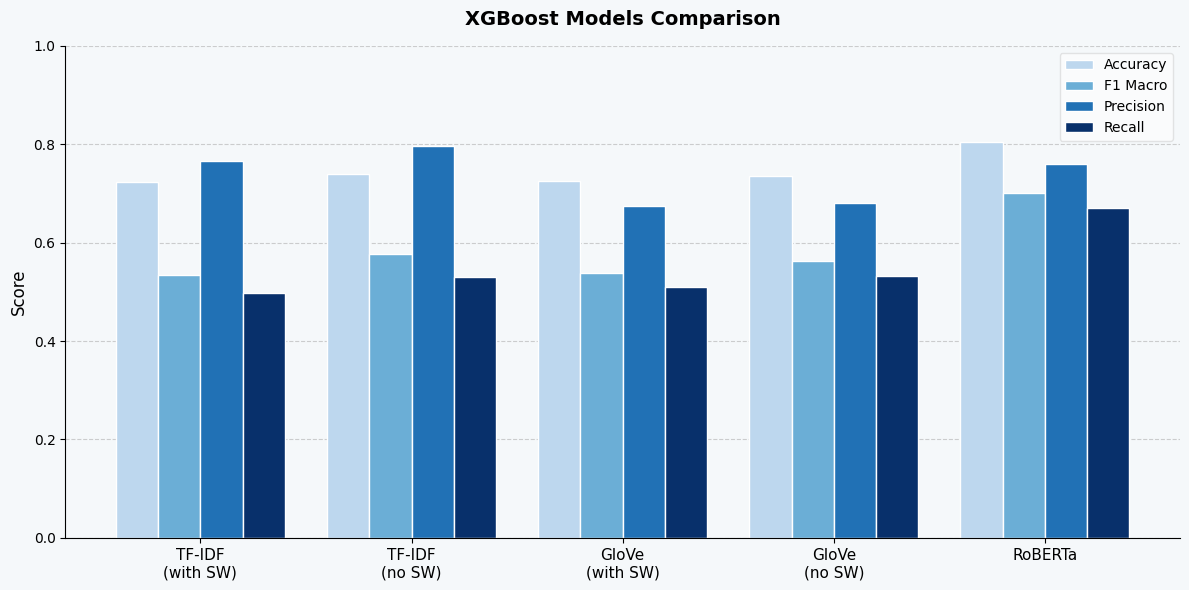

In [19]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "TF-IDF\n(with SW)",
    "TF-IDF\n(no SW)",
    "GloVe\n(with SW)",
    "GloVe\n(no SW)",
    "RoBERTa"
]

accuracy  = [xgb_idf_accuracy_no_sw,  xgb_idf_accuracy,  xgb_glove_accuracy_no_sw,  xgb_glove_accuracy,  xgb_roberta_accuracy]
f1_macro  = [xgb_idf_f1_macro_no_sw,  xgb_idf_f1_macro,  xgb_glove_f1_macro_no_sw,  xgb_glove_f1_macro,  xgb_roberta_f1_macro]
precision = [xgb_idf_precision_no_sw, xgb_idf_precision, xgb_glove_precision_no_sw, xgb_glove_precision, xgb_roberta_precision]
recall    = [xgb_idf_recall_no_sw,    xgb_idf_recall,    xgb_glove_recall_no_sw,    xgb_glove_recall,    xgb_roberta_recall]

x = np.arange(len(models))
width = 0.2

colors = ['#BDD7EE', '#6BAED6', '#2171B5', '#08306B']

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F5F8FA')
ax.set_facecolor('#F5F8FA')

ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color=colors[0], edgecolor='white')
ax.bar(x - 0.5*width, f1_macro,  width, label='F1 Macro',  color=colors[1], edgecolor='white')
ax.bar(x + 0.5*width, precision, width, label='Precision', color=colors[2], edgecolor='white')
ax.bar(x + 1.5*width, recall,    width, label='Recall',    color=colors[3], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("XGBoost Models Comparison", fontsize=14, fontweight='bold', pad=15)
ax.legend(framealpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Among all models, the one with better score was Roberta, with the highest F1 Macro and Recall. Accuracy is not a great measure since our class is imbalanced.

We will do GridSearch with Roberta to see if we improve our model.

In [16]:
## GridSearchCV for XGBoost with RoBERTa

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

clf_grid = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=13
)

grid_search = GridSearchCV(
    estimator=clf_grid,
    param_grid=param_grid,
    scoring='f1_macro',   # optimiza para F1 Macro
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_roberta, y_train_raw)

print("Best params:", grid_search.best_params_)
print("Best F1 Macro (CV):", grid_search.best_score_)

# Avaliar no validation
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(X_train_roberta)
y_pred_val = best_model.predict(X_val_roberta)

xgb_roberta_accuracy_grid, xgb_roberta_f1_macro_grid, xgb_roberta_precision_grid, xgb_roberta_recall_grid = evaluate_model_predictions(
    y_pred_train, y_pred_val, y_train=y_train_raw, y_val=y_val_raw
)



Fitting 3 folds for each of 108 candidates, totalling 324 fits


c:\Users\calco\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:18:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best F1 Macro (CV): 0.7474496842753355
Accuracy of train: 0.9993
F1 Macro (Train): 0.9992
Accuracy of val: 0.8250
F1 Macro (Val): 0.7520
Precision (Val): 0.7860
Recall (Val): 0.7271

Confusion Matrix for Validation Data:
[[ 172   28   88]
 [  27  251  107]
 [  32   52 1152]]

Classification Report for Validation Data:
              precision    recall  f1-score   support

           0       0.74      0.60      0.66       288
           1       0.76      0.65      0.70       385
           2       0.86      0.93      0.89      1236

    accuracy                           0.83      1909
   macro avg       0.79      0.73      0.75      1909
weighted avg       0.82      0.83      0.82      1909



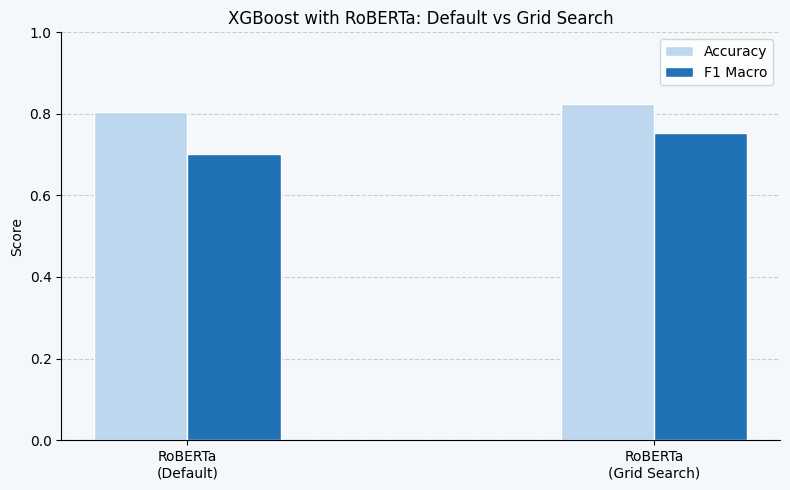

In [23]:
models = ["RoBERTa\n(Default)", "RoBERTa\n(Grid Search)"]
accuracy  = [xgb_roberta_accuracy, xgb_roberta_accuracy_grid]
f1_macro  = [xgb_roberta_f1_macro, xgb_roberta_f1_macro_grid]
precision = [xgb_roberta_precision, xgb_roberta_precision_grid]
recall    = [xgb_roberta_recall, xgb_roberta_recall_grid]
x = np.arange(len(models))
width = 0.2
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F5F8FA')
ax.set_facecolor('#F5F8FA')
ax.bar(x - width/2, accuracy,  width, label='Accuracy',  color='#BDD7EE', edgecolor='white')
ax.bar(x + width/2, f1_macro,  width, label='F1 Macro',  color='#2171B5', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("XGBoost with RoBERTa: Default vs Grid Search")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Grid Search improved the original model.

The final model was:

### Cross-Validation Performance

- **Best F1 Macro (3-fold CV):** `0.7474`

### Training Performance

| Metric | Score |
|---------|--------|
| Accuracy | 0.9993 |
| F1 Macro | 0.9992 |

### Validation Performance

| Metric | Score |
|---------|--------|
| Accuracy | 0.8250 |
| F1 Macro | **0.7520** |
| Precision (Macro) | 0.7860 |
| Recall (Macro) | 0.7271 |


Given the class imbalance observed in the dataset, the **macro F1-score (0.7520)** provides a more informative measure of performance than accuracy alone, as it evaluates the model's effectiveness across all classes equally.

We can see that we have overfitting, which can being caused because of class imbalance.